
This section explores safety-related patterns in the data to better understand the factors contributing to incidents. The analysis focuses on identifying trends, frequencies, and potential risk indicators associated with safety events.




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_safety_incidents

Path to dataset files: C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1


In [2]:
# Set the default figure size
plt.rcParams['figure.figsize'] = (10, 6)
sns.set(color_codes = True)
pd.set_option('display.width', 1200)
pd.set_option('display.max_columns', None)

In [3]:
#dataframe
safety_df = load_safety_incidents()
print(safety_df.isnull().sum())

incident_id            0
trip_id                0
truck_id               1
driver_id              1
incident_date          0
incident_type          0
location_city          0
location_state         0
at_fault_flag          0
injury_flag            0
vehicle_damage_cost    0
cargo_damage_cost      0
claim_amount           0
preventable_flag       0
description            0
dtype: int64


In [4]:
#unique descriptions
safety_df.description.unique()

array(['Severe incident involving equipment',
       'Severe incident involving weather',
       'Minor incident involving traffic',
       'Moderate incident involving equipment',
       'Minor incident involving other driver',
       'Minor incident involving weather',
       'Moderate incident involving traffic',
       'Moderate incident involving weather',
       'Severe incident involving traffic',
       'Minor incident involving equipment',
       'Severe incident involving other driver',
       'Moderate incident involving other driver'], dtype=object)

In [5]:
#convert to datetime
safety_df['incident_date']=pd.to_datetime(safety_df['incident_date'])
safety_df['year']=pd.to_datetime(safety_df['incident_date']).dt.year
safety_df['month_year']=pd.to_datetime(safety_df['incident_date']).dt.to_period('M')

In [6]:
#inspect data
print(safety_df.head())

   incident_id       trip_id  truck_id driver_id       incident_date       incident_type location_city location_state  at_fault_flag  injury_flag  vehicle_damage_cost  cargo_damage_cost  claim_amount  preventable_flag                            description  year month_year
0  INC00000001  TRIP00036079  TRK00006  DRV00006 2023-04-09 14:00:00    Moving Violation      Columbus             PA           True        False             12629.26               0.00      12629.26              True    Severe incident involving equipment  2023    2023-04
1  INC00000002  TRIP00032462  TRK00084  DRV00006 2023-02-19 11:00:00    Moving Violation      Columbus             NC          False        False              2700.70           14284.24      16984.94             False      Severe incident involving weather  2023    2023-02
2  INC00000003  TRIP00067583  TRK00106  DRV00119 2024-05-20 01:00:00  Customer Complaint       Seattle             OK           True        False             24302.32            

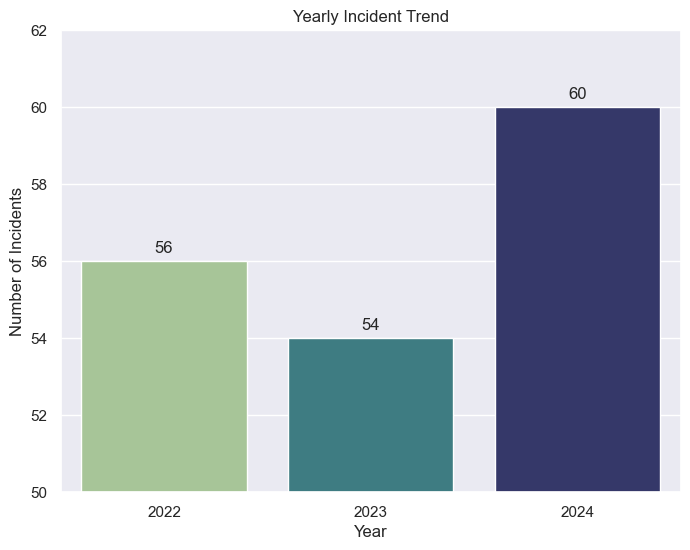

In [7]:
#plot incident trend
yearly_incidents = (
    safety_df.groupby('year')['incident_id']
    .count()
    .reset_index()
)

plt.figure(figsize=(8, 6))

# Update: Assign x to hue and set legend=False to satisfy the new Seaborn requirements
ax = sns.barplot(
    data=yearly_incidents, 
    x='year', 
    y='incident_id', 
    hue='year', 
    palette='crest', 
    legend=False
)

# THE TRICK: Zoom in on the Y-axis to make the jump from 54 to 60 look more dramatic
# Since your min is 54 and max is 60, starting at 50 makes the change very clear
plt.ylim(50, 62) 

# Add data labels on top of the bars so the exact numbers are visible
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.title('Yearly Incident Trend')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.show()


<div style="font-size:20px"> Relationship between Features and preventable cases </div>

In [8]:

# Create a function to show the relationships between preventable cases and other categories
def bar_charts_preventable(df, feature):
    import matplotlib.pyplot as plt

    _agg = {'incident_id': 'count'}
    _groupby = ['year', 'preventable_flag', feature]

    df_feature = (
        df.groupby(_groupby)
          .agg(_agg)
          .reset_index()
    )

    years = sorted(df_feature['year'].unique())

    fig, axes = plt.subplots(1, len(years), figsize=(20, 6), sharey=True)

    handles, labels = None, None

    for ax, year in zip(axes, years):
        subset = df_feature[df_feature['year'] == year]

        plot_df = subset.pivot(
            index='preventable_flag',
            columns=feature,
            values='incident_id'
        )

        ax_plot = plot_df.plot(kind='bar', ax=ax, legend=False)

        if handles is None:
            handles, labels = ax_plot.get_legend_handles_labels()

        ax.set_title(f'Year {year}',fontsize=16, fontweight='bold')
        ax.set_xlabel('Preventable',fontsize=14, fontweight='bold')
        ax.set_xticklabels(['No', 'Yes'], rotation=0)

    axes[0].set_ylabel('Incident Count')

    # Shared legend outside
    fig.legend(
        handles,
        labels,
        title=feature,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5)
    )

    plt.tight_layout()
    plt.show()



<div style="font-size:20px"> Charts </div>

In [9]:
# Create a mapping function
def categorize_description(desc):
    if 'equipment' in desc:
        return 'Equipment'
    elif 'driver' in desc:
        return 'Other Driver' 
    elif 'traffic' in desc:
        return 'Traffic'       
    else:
        return 'Weather'

# Apply to dataframe
safety_df['category'] = safety_df['description'].apply(categorize_description)

<div style="font-size:20px"> Preventable incidents by Cause Category </div>

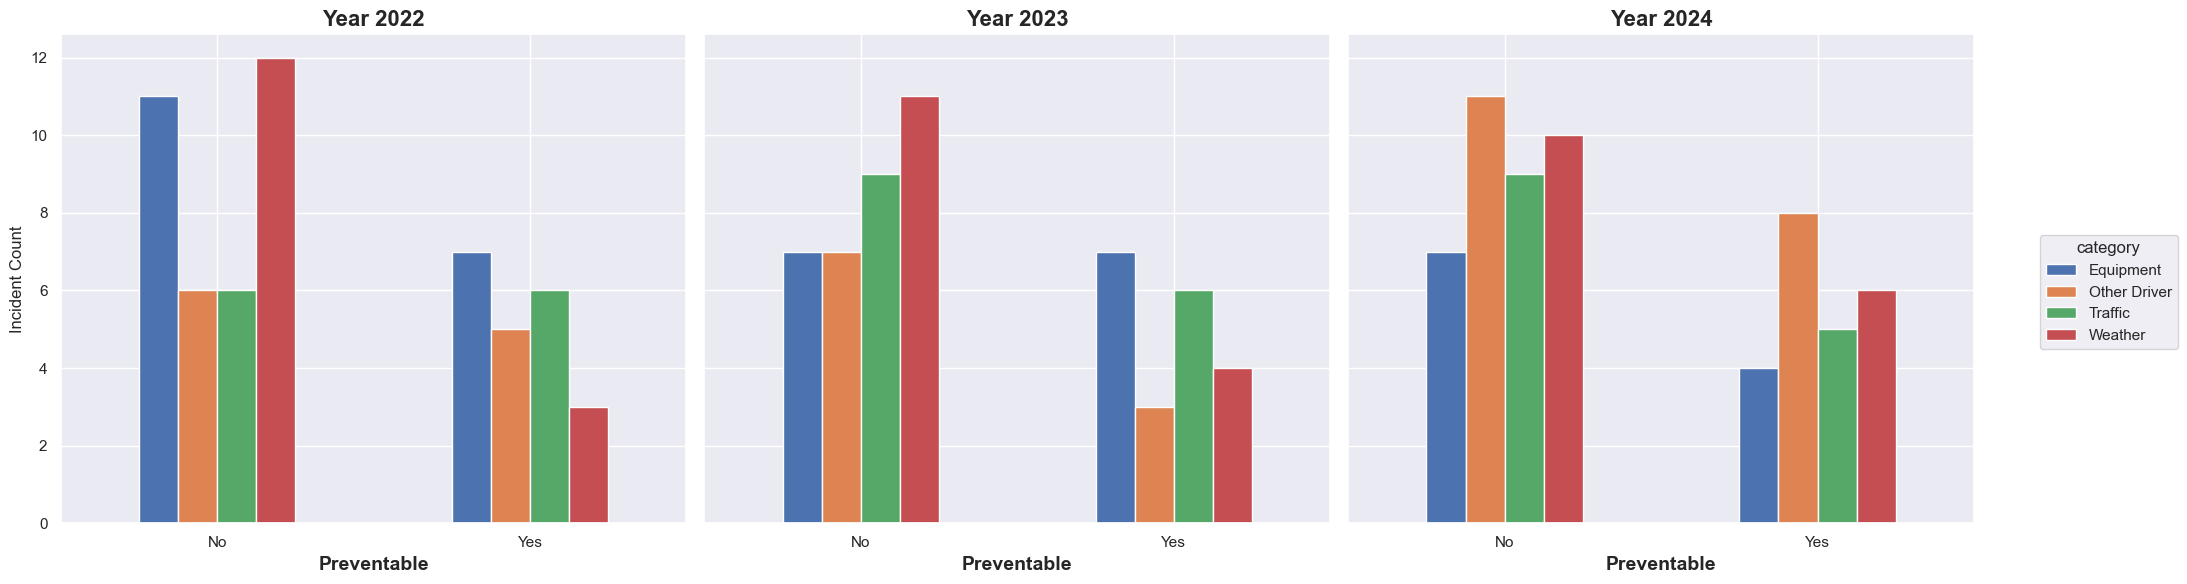

In [10]:
bar_charts_preventable(safety_df, 'category')

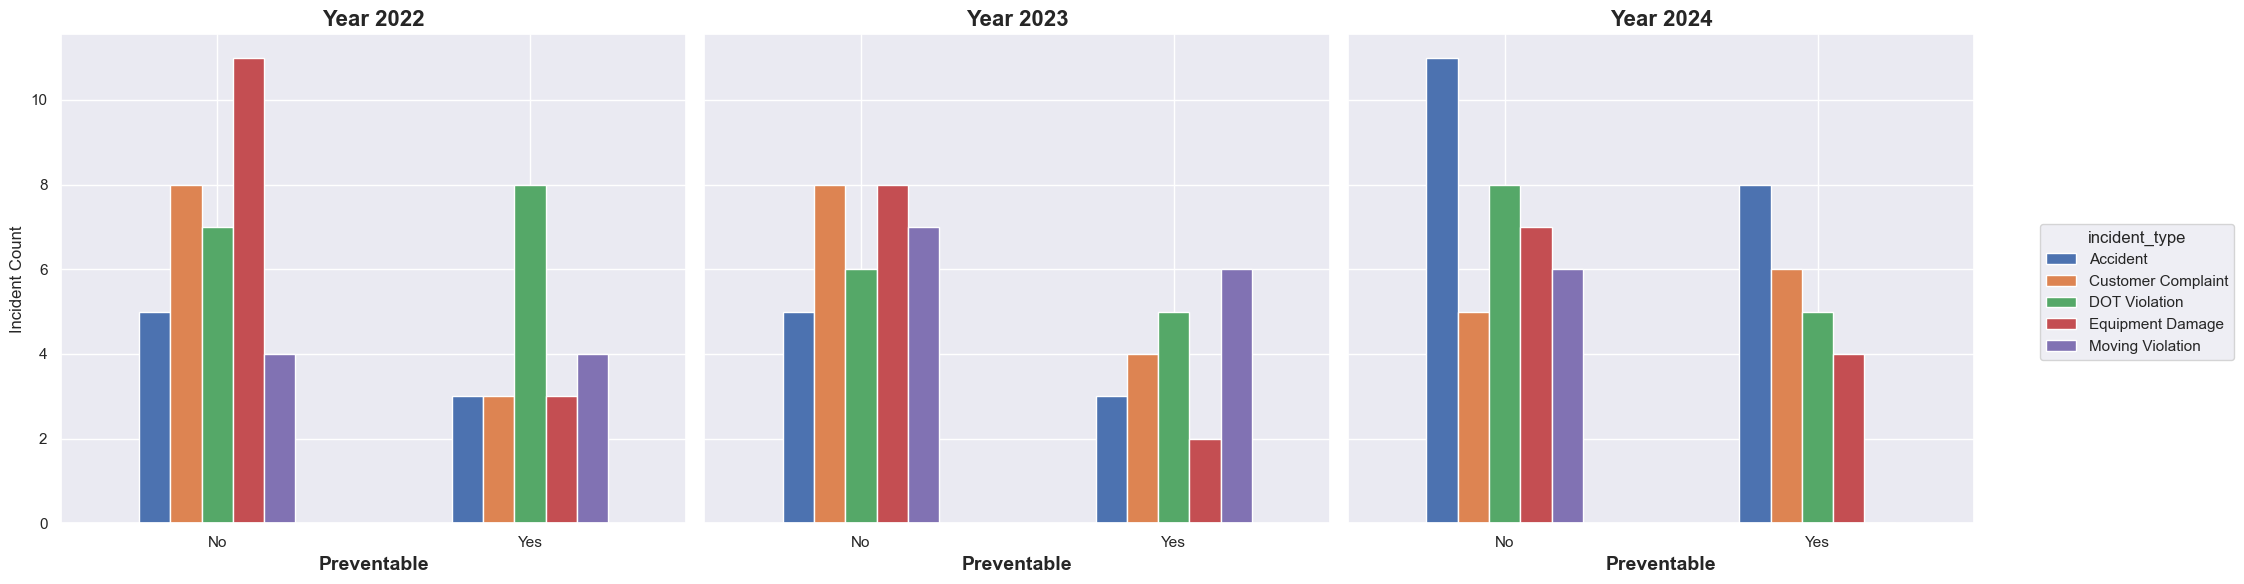

In [11]:
bar_charts_preventable(safety_df, 'incident_type')

<div style="font-size:20px"> Preventable incidents by Fault Category </div>

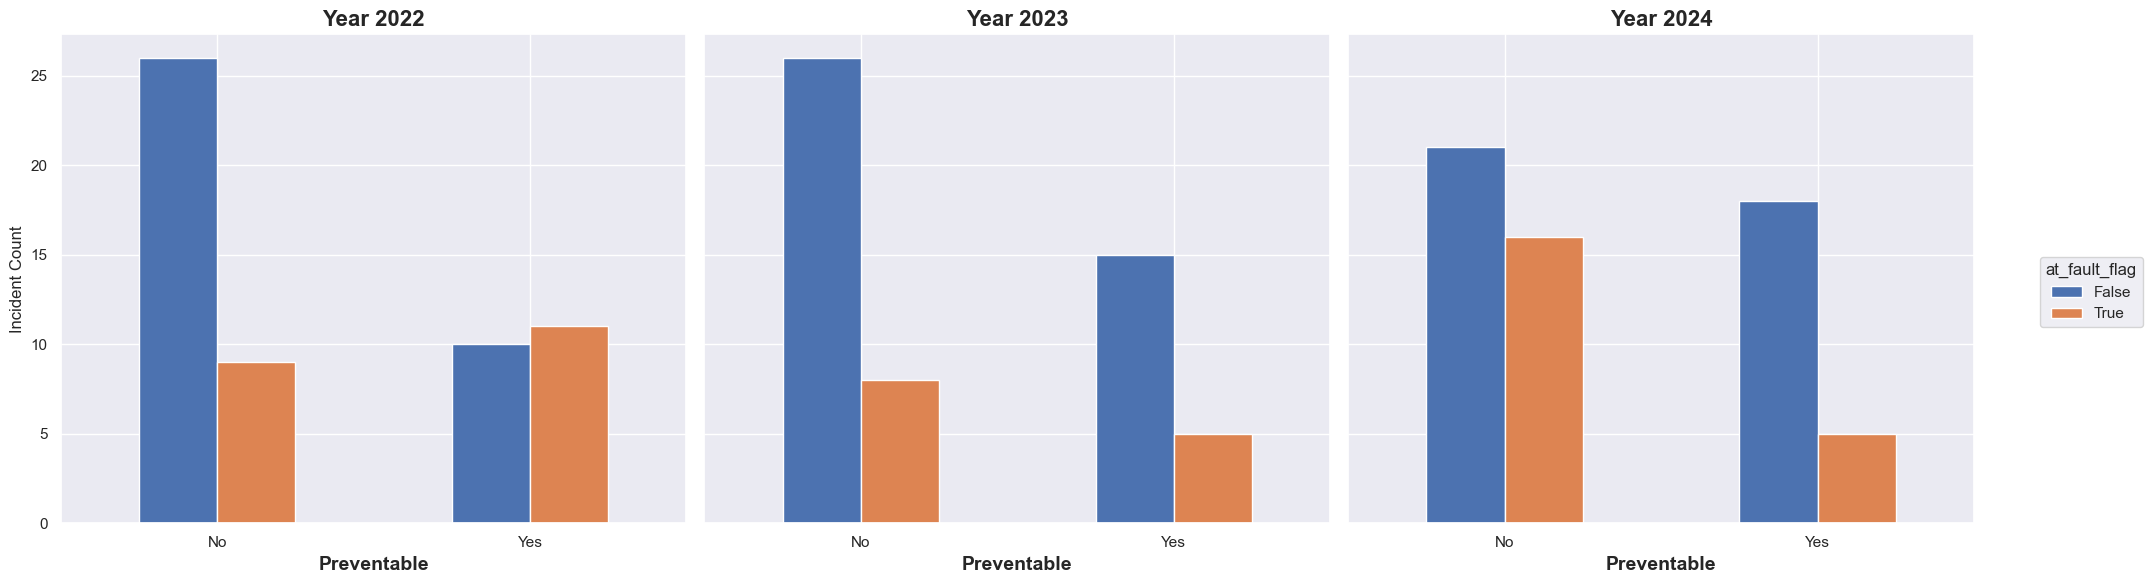

In [12]:
bar_charts_preventable(safety_df, 'at_fault_flag')

In [13]:
def bar_charts_at_fault_flag(df, feature):
    import matplotlib.pyplot as plt

    _agg = {'incident_id': 'count'}
    _groupby = ['year', 'at_fault_flag', feature]

    df_feature = (
        df.groupby(_groupby)
          .agg(_agg)
          .reset_index()
    )

    years = sorted(df_feature['year'].unique())

    fig, axes = plt.subplots(1, len(years), figsize=(20, 6), sharey=True)

    handles, labels = None, None

    for ax, year in zip(axes, years):
        subset = df_feature[df_feature['year'] == year]

        plot_df = subset.pivot(
            index='at_fault_flag',
            columns=feature,
            values='incident_id'
        )

        ax_plot = plot_df.plot(kind='bar', ax=ax, legend=False)

        if handles is None:
            handles, labels = ax_plot.get_legend_handles_labels()

        ax.set_title(f'Year {year}',fontsize=16, fontweight='bold')
        ax.set_xlabel('at_fault',fontsize=14, fontweight='bold')
        ax.set_xticklabels(['No', 'Yes'], rotation=0)

    axes[0].set_ylabel('Incident Count')

    # 🔑 Shared legend outside
    fig.legend(
        handles,
        labels,
        title=feature,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5)
    )

    plt.tight_layout()
    plt.show()


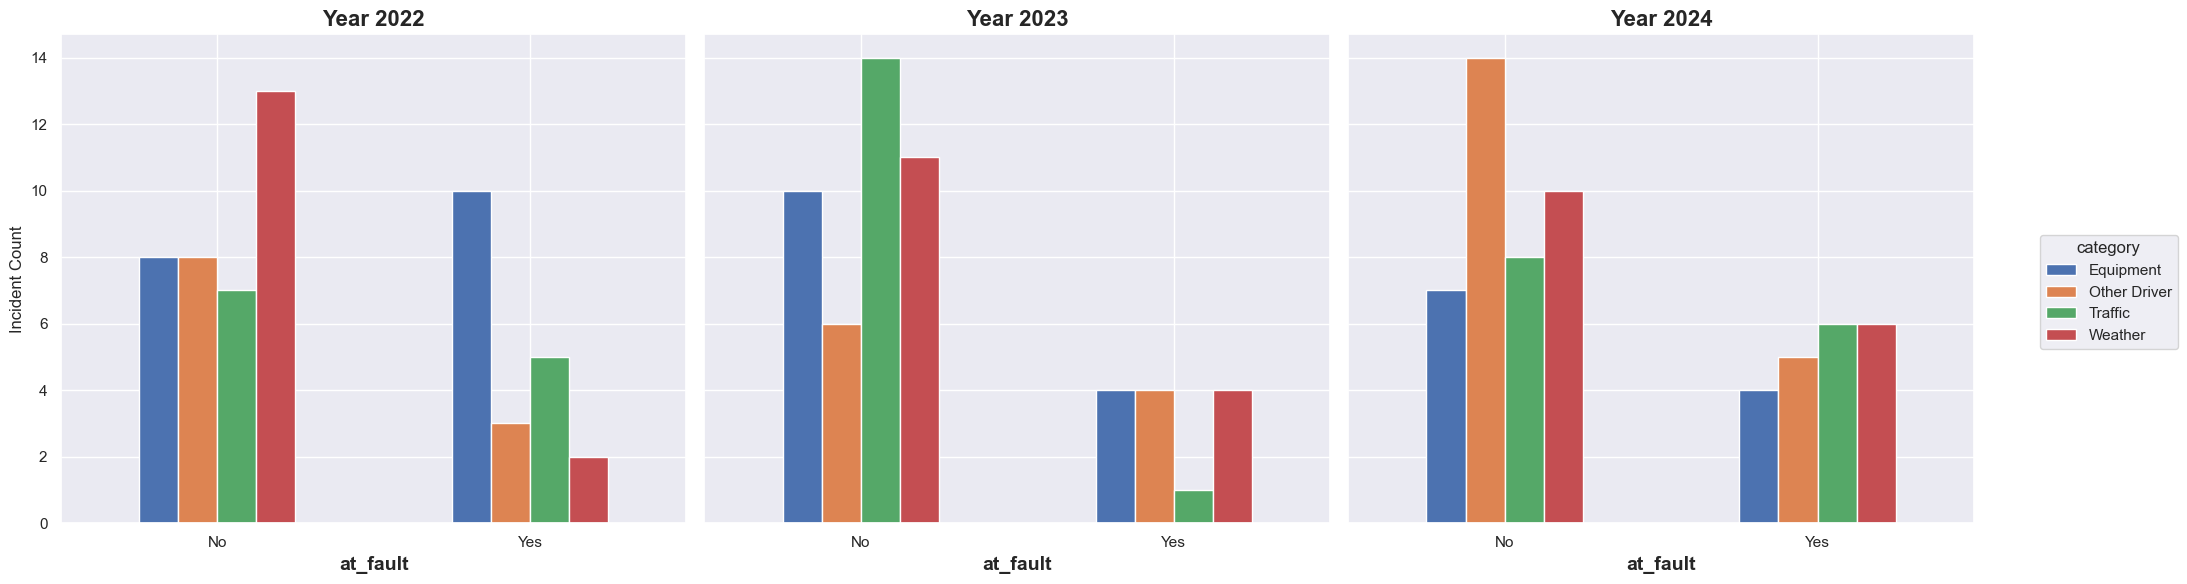

In [14]:
bar_charts_at_fault_flag(safety_df, 'category')

In [15]:
safety_df.groupby(['location_state'])['at_fault_flag'].count()

location_state
AZ     6
CA     5
CO     7
FL     6
GA     8
IL     6
IN     6
MI     6
MN     5
MO     8
NC     9
NE     8
NV     6
NY     7
OH    11
OK     4
OR     7
PA    10
TN    18
TX    14
UT     6
WA     3
WI     4
Name: at_fault_flag, dtype: int64

In [16]:
state_counts = (
    safety_df.groupby("location_state")
    .size()
    .reset_index(name="incident_count")
)
state_map = {
    "AL":"Alabama","AK":"Alaska","AZ":"Arizona","AR":"Arkansas","CA":"California",
    "CO":"Colorado","CT":"Connecticut","DE":"Delaware","FL":"Florida","GA":"Georgia",
    "HI":"Hawaii","ID":"Idaho","IL":"Illinois","IN":"Indiana","IA":"Iowa",
    "KS":"Kansas","KY":"Kentucky","LA":"Louisiana","ME":"Maine","MD":"Maryland",
    "MA":"Massachusetts","MI":"Michigan","MN":"Minnesota","MS":"Mississippi",
    "MO":"Missouri","MT":"Montana","NE":"Nebraska","NV":"Nevada","NH":"New Hampshire",
    "NJ":"New Jersey","NM":"New Mexico","NY":"New York","NC":"North Carolina",
    "ND":"North Dakota","OH":"Ohio","OK":"Oklahoma","OR":"Oregon","PA":"Pennsylvania",
    "RI":"Rhode Island","SC":"South Carolina","SD":"South Dakota","TN":"Tennessee",
    "TX":"Texas","UT":"Utah","VT":"Vermont","VA":"Virginia","WA":"Washington",
    "WV":"West Virginia","WI":"Wisconsin","WY":"Wyoming"
}

state_counts["state_name"] = state_counts["location_state"].map(state_map)
state_counts["location"] = state_counts["state_name"] + ", USA"
print(state_counts.nunique())

location_state    23
incident_count    11
state_name        23
location          23
dtype: int64


from geopy.geocoders import Nominatim

geolocator = Nominatim(user_agent="incident_map")
coords = {}

for loc in state_counts["location"]:
    try:
        geo = geolocator.geocode(loc)
        coords[loc] = (geo.latitude, geo.longitude)
    except:
        coords[loc] = (None, None)

state_counts["lat"] = state_counts["location"].map(lambda x: coords[x][0])
state_counts["lon"] = state_counts["location"].map(lambda x: coords[x][1])

In [17]:
import time
from geopy.geocoders import Nominatim

geolocator = Nominatim(user_agent="incident_map", timeout=10)
coords = {}

for loc in state_counts["location"]:
    try:
        geo = geolocator.geocode(loc)
        if geo is not None:
            coords[loc] = (geo.latitude, geo.longitude)
        else:
            print("No result:", loc)
            coords[loc] = (None, None)
        time.sleep(1)   # avoid rate limiting
    except Exception as e:
        print("Error for", loc, ":", e)
        coords[loc] = (None, None)

In [18]:
state_counts["lat"] = state_counts["location"].map(lambda x: coords[x][0])
state_counts["lon"] = state_counts["location"].map(lambda x: coords[x][1])

In [19]:
total_locations = len(state_counts)
print("Total locations before filtering:", total_locations)

Total locations before filtering: 23


In [20]:
failed_locations = state_counts["lat"].isna().sum()
failed_locations_details=state_counts[state_counts["lat"].isna()]
print("Locations that failed geocoding:", failed_locations,failed_locations_details)

Locations that failed geocoding: 0 Empty DataFrame
Columns: [location_state, incident_count, state_name, location, lat, lon]
Index: []


In [21]:
valid_locations = state_counts["lat"].notna().sum()

print("Valid locations for mapping:", valid_locations)

Valid locations for mapping: 23


In [22]:
state_counts = state_counts.dropna(subset=["lat", "lon"])

In [23]:
import folium

m = folium.Map(location=[39, -98], zoom_start=4, width=700, height=450)

for _, row in state_counts.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=max(5, row["incident_count"] * 2),
        color="red",
        fill=True,
        fill_opacity=0.7,
        popup=f"{row['location_state']}<br>Incidents: {row['incident_count']}"
    ).add_to(m)

m